In [17]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.1 MB/s eta 0:00:00


In [1]:
import pandas as pd
from sklearn.utils import shuffle

In [2]:
fake_df = pd.read_csv("Fake.csv")
real_df = pd.read_csv("True.csv")

fake_df["label"] = 0   # Fake
real_df["label"] = 1   # Real

df = pd.concat([fake_df, real_df], axis=0, ignore_index=True)

df = shuffle(df, random_state=42).reset_index(drop=True)

print(df.shape)
print(df["label"].value_counts())

(44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [4]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [5]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [6]:
df=df.drop(['date'],axis=1)

In [7]:
df['combined_text']=df[['title','text','subject']].agg(" ".join,axis=1)

In [8]:
df.head()

,title,text,subject,label,combined_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,1,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,0,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,1,Donald Trump heads for Scotland to reopen a go...


In [9]:
df=df.drop(['title','text','subject'],axis=1)

In [10]:
df.head()

,label,combined_text
0,0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,1,Trump drops Steve Bannon from National Securit...
2,1,Puerto Rico expects U.S. to lift Jones Act shi...
3,0,OOPS: Trump Just Accidentally Confirmed He Le...
4,1,Donald Trump heads for Scotland to reopen a go...


In [11]:
import re
import string

def clean_text(text):
  text=text.lower()
  text=re.sub(r"http\S+|www\.\S+","",text)
  text=re.sub(r"<.*?>","",text)
  text=text.translate(str.maketrans("", "", string.punctuation))
  text=re.sub(r"\d+","",text)
  text=re.sub("[\U0001F600-\U0001FFFF]","",text)
  return text

In [12]:
df['combined_text']=df['combined_text'].apply(clean_text)

In [13]:
x=df['combined_text']
y=df['label']

In [14]:
from sklearn.model_selection import train_test_split
x_train_final,x_test,y_train_final,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [15]:
print(x_train_final.shape)
print(x_test.shape)
print(y_train_final.shape)
print(y_test.shape)
print(y_test.value_counts())

(35918,)
(8980,)
(35918,)
(8980,)
label
0    4696
1    4284
Name: count, dtype: int64


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(stop_words="english",max_features=50000,ngram_range=(1, 2))
x_train_final=vectorizer.fit_transform(x_train_final)
x_test=vectorizer.transform(x_test)

In [19]:
import optuna
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
def objective(trial):
    params = {
        "loss": trial.suggest_categorical("loss",["hinge","log_loss","modified_huber","perceptron","squared_hinge"]),
        "penalty": trial.suggest_categorical("penalty",["l2","l1","elasticnet"]),
        "alpha": trial.suggest_float("alpha",1e-6,1e-2,log=True),
        "learning_rate": trial.suggest_categorical("learning_rate",["optimal","adaptive","invscaling","constant"]),
        "max_iter": trial.suggest_int("max_iter",1000,5000),
        "eta0": trial.suggest_float("eta0",1e-4,1e-1,log=True),
        "random_state": 42,
        "n_jobs": -1
    }
    model = SGDClassifier(**params)
    score = cross_val_score(
        model,
        x_train_final,
        y_train_final,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    ).mean()
    return score
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)
print("Best Accuracy :", study.best_value)
print("Best Params :")
print(study.best_params)

[I 2026-07-19 16:15:02,076] A new study created in memory with name: no-name-fd7f57ba-38c8-4c7d-b743-3217167c1822


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-19 16:15:03,523] Trial 0 finished with value: 0.9347960557242585 and parameters: {'loss': 'log_loss', 'penalty': 'elasticnet', 'alpha': 0.00025378155082656634, 'learning_rate': 'invscaling', 'max_iter': 1849, 'eta0': 0.0003511356313970409}. Best is trial 0 with value: 0.9347960557242585.
[I 2026-07-19 16:15:13,181] Trial 1 finished with value: 0.9803720118047469 and parameters: {'loss': 'modified_huber', 'penalty': 'l2', 'alpha': 2.9204338471814107e-05, 'learning_rate': 'adaptive', 'max_iter': 3370, 'eta0': 0.000137832374550072}. Best is trial 1 with value: 0.9803720118047469.
[I 2026-07-19 16:15:14,110] Trial 2 finished with value: 0.9364665296821326 and parameters: {'loss': 'squared_hinge', 'penalty': 'l2', 'alpha': 0.0005456725485601478, 'learning_rate': 'invscaling', 'max_iter': 4638, 'eta0': 0.0005975027999960298}. Best is trial 1 with value: 0.9803720118047469.
[I 2026-07-19 16:15:18,204] Trial 3 finished with value: 0.9608831675665689 and parameters: {'loss': 'hinge',

In [20]:
model=SGDClassifier(**study.best_params)
model.fit(x_train_final,y_train_final)

SGDClassifier(alpha=2.5269115753920255e-05, eta0=0.049826158907385884,
              max_iter=1561, penalty='l1')

In [21]:
pred=model.predict(x_test)

In [23]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve, auc,precision_recall_curve

In [24]:
print(accuracy_score(y_test,pred))

0.9979955456570155


In [25]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [27]:
cm=confusion_matrix(y_test,pred)
print(cm)

[[4687    9]
 [   9 4275]]


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

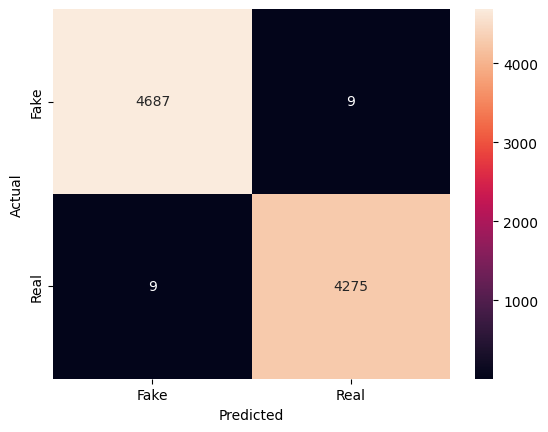

In [29]:
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['Fake','Real'],yticklabels=['Fake','Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

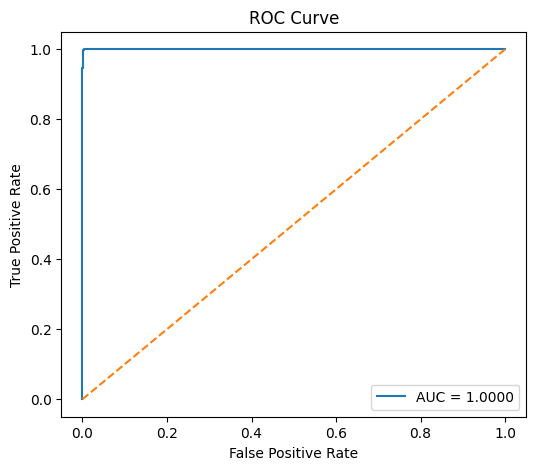

In [31]:
from sklearn.metrics import roc_curve, auc
y_score = model.decision_function(x_test)
fpr, tpr, _ = roc_curve(y_test, y_score)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

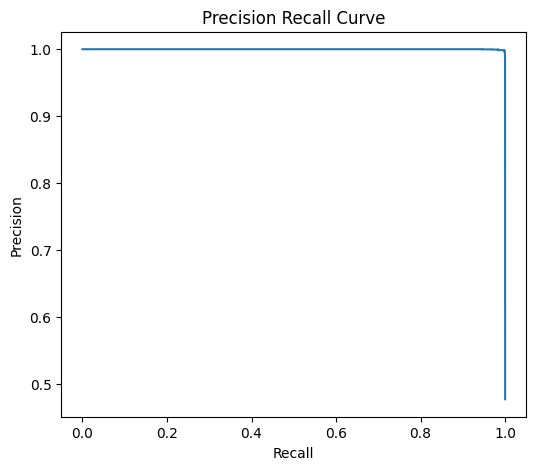

In [32]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test,y_score)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [34]:
import joblib
joblib.dump(model,"sgd_fake_news.pkl")
joblib.dump(vectorizer,"tfidf.pkl")

['tfidf.pkl']